# Understanding Experimental Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

- Now we have faced data and we want to experimetns, we want to do inference, to understand this data and make conclusions on it, usually we have qusetions and we want to answer them ... so we need to use data!

- It is really common to have experimental data (collected from science experiments, polls, etc) and we want to understand the relationship between two features so that we could make predicions, or maybe we arleady have an hypothesis about that relationship and we want to test it with real information

# 1. Reading the data

In [2]:
def getData(fileName):
    """
    This can be totally done wtih pandas, but lets stick to the orignal material
    it would be a great exercise to use and keep learning python
    """

    dataFile = open(fileName, "r")
    distances = []
    masses = []
    dataFile.readline()  # descard header
    for line in dataFile:
        d, m = line.split()
        distances.append(float(d))
        masses.append(float(m))

    dataFile.close()
    return (masses, distances)


def labelPlot():
    plt.title("Measured Displacement of Spring")
    plt.xlabel("|Force| (Newtons)")
    plt.ylabel("Distance (meters)")


def plotData(fileName):
    xVals, yVals = getData(fileName)
    xVals = np.array(xVals)
    yVals = np.array(yVals)
    xVals = xVals * 9.81  # acc due to gravity
    plt.plot(xVals, yVals, "bo", label="Measured displacements")
    plt.show()


def fitData(fileName):
    xVals, yVals = getData(fileName)
    xVals = np.array(xVals)
    yVals = np.array(yVals)
    xVals = xVals * 9.81  # get force
    plt.plot(xVals, yVals, "bo", label="measured points")
    labelPlot()
    a, b = np.polyfit(xVals, yVals, 1)  # linear regression with a polynomy of degree 1
    estYvals = a * np.array(xVals) + b
    print(f"a = {a} \n b = {b}")
    plt.plot(xVals, estYvals, "r", label=f"Linear fit, k = {round(1/a, 5)} ")
    plt.legend()
    plt.show()

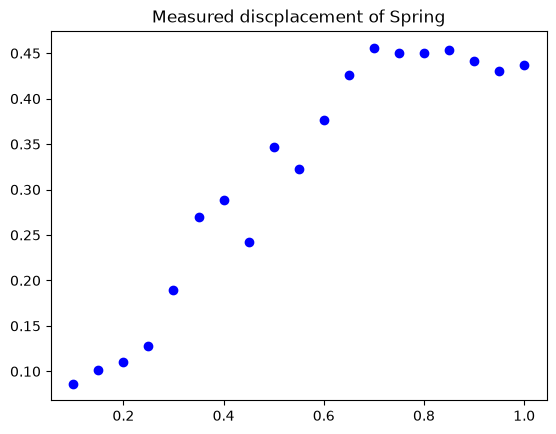

In [3]:
x, y = getData("../data/springData.txt")

plt.plot(x, y, "bo")
plt.title("Measured discplacement of Spring")
plt.show()

# Fitting curves to data

1. When we fit a curve of a set of data we want to find the relationship that best relates an independent variable (the mass for this case) to an estimated avlue of dependent variable (the distance)

2. To decide how well a curve fits thte data, we need to measure the goodness of the fit, **called the objective function**

3. Once we define it , we want to find the curve that minimizes it!

4. In this case, we want to find a line such that some function of the sum of the distances from the line to the measured point is minizmied!

5. How? using **Linear Regression**: We will have a estimated polynomial, how can we know that the function is working? measing the errors! HOw much are we deviating from the real value? So we take the deviations... square them and sum them, to have a measurement of error... it is really similar to the **variance**! just before dividing it by n. This is the **least squares objective function**



### Solving for least squares:

1. Lets do a sipmle example: We are using a degree-one polynomial, y = ax + b, as a model for our data 

2. We want to find the values for a and b such that when we use the polynomial to compute the values of y given x, the least squares function is minimized!

3. This is done by doing the newton's methdo

a = 0.046432033192052496 
 b = 0.06562859649122826


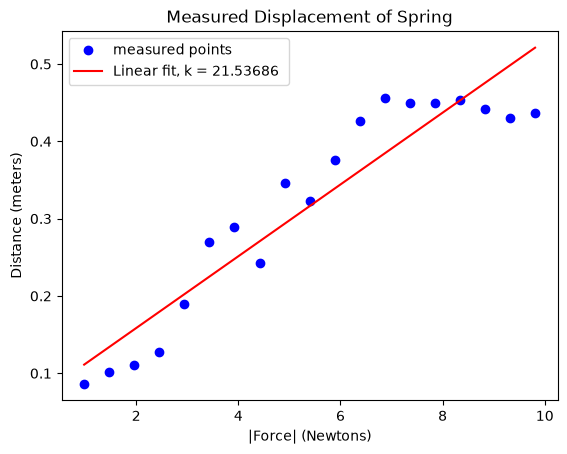

In [4]:
fitData("../data/springData.txt")

### Version using polyval

In [5]:
def fitData1(fileName):
    xVals, yVals = getData(fileName)
    xVals = np.array(xVals)
    yVals = np.array(yVals)
    xVals = xVals * 9.81
    plt.plot(xVals, yVals, "bo", label="Measured points")
    labelPlot()
    model = np.polyfit(xVals, yVals, 1)
    estyVals = np.polyval(model, xVals)
    plt.plot(xVals, estyVals, "r", label=f"Linear fit, k = {round(1/model[0],5)}")
    plt.legend(loc="best")
    plt.show()

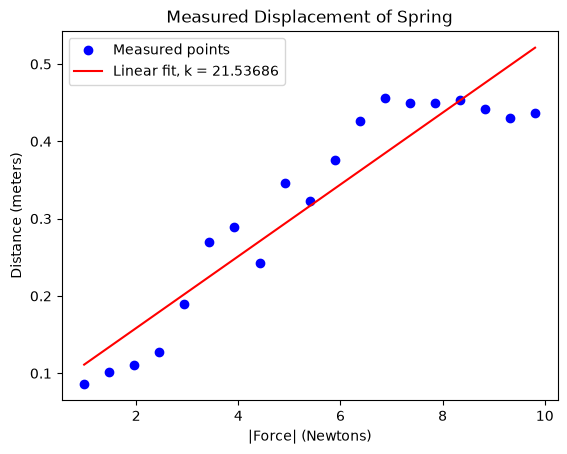

In [6]:
fitData1("../data/springData.txt")

## Another experiment

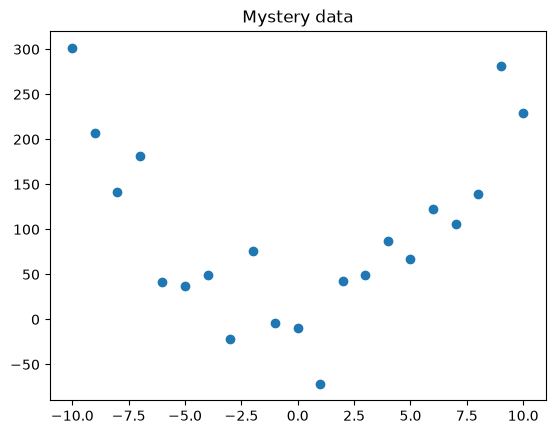

In [7]:
xVals, yVals = getData("../data/mysteryData.txt")
plt.plot(xVals, yVals, "o", label="Mistery Data Points")
plt.title("Mystery data")
plt.show()

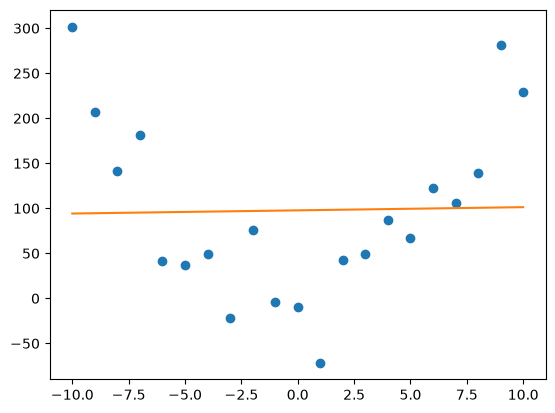

In [8]:
# lets try a linea model

model1 = np.polyfit(xVals, yVals, 1)
plt.plot(xVals, yVals, "o", label="Mystery Data Points")
plt.plot(xVals, np.polyval(model1, xVals), label="Linear model")
plt.show()

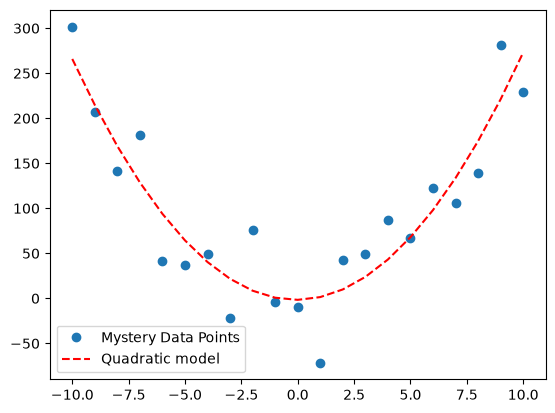

In [9]:
# lets try a quadratic mdoel

model2 = np.polyfit(xVals, yVals, 2)
plt.plot(xVals, yVals, "o", label="Mystery Data Points")
plt.plot(xVals, np.polyval(model2, xVals), "r--", label="Quadratic model")
plt.legend()
plt.show()

## But how can we know if these models are good or bad? how can we compare them?

In [10]:
## compare models:


def aveMeanSquareError(data, predicted):
    error = 0.0
    for i in range(len(data)):
        error += (data[i] - predicted[i]) ** 2

    return error / len(data)

In [11]:
estYVals = np.polyval(model1, xVals)
print(
    f" Ave. mean square error for linear model = {aveMeanSquareError(yVals, estYVals)}"
)
estYVals = np.polyval(model2, xVals)
print(
    f" Ave. mean square error for quadratic model = {aveMeanSquareError(yVals, estYVals)}"
)

 Ave. mean square error for linear model = 9372.730789652878
 Ave. mean square error for quadratic model = 1524.0204471835439


- The quadratic model 6 times better than the linear model... but 

- Can we really trust on this metric? NO! THe evarage mean squared error is not scale independent, we can easily manipulate the scale of our features in order to reduce this metric,

-  So we need a scale indpendent metric

In [20]:
def rSquared(observed, predicted):
    squaredError = ((predicted - observed) ** 2).sum()
    meanSquaredError = squaredError / len(observed)

    return 1 - meanSquaredError / np.var(observed)


def genFits(xVals, yVals, degrees):
    models = []
    for d in degrees:
        model = np.polyfit(xVals, yVals, d)
        models.append(model)

    return models


def testFits(models, degrees, xVals, yVals, title):
    plt.plot(xVals, yVals, "o", label="Data")

    for i in range(len(models)):
        estyVals = np.polyval(models[i], xVals)

        r2 = rSquared(yVals, estyVals)

        plt.plot(
            xVals, estyVals, label=f"Fit of degree {degrees[i]}, R2 = {round(r2, 5)}"
        )

    plt.legend(loc="best")
    plt.title(title)
    plt.show()

- The R2 is an amazing metric , it compares how much has deviated our prediccions from the real observations (squared) and how much the real obersvations deviate from the realm mean,

- Bascially we are comparing our least squared errors with the variance before diviing to n! 

- And then, subtracting 1 from it, why? Because if both metrics are similar, means that our prediccions have captured all the variance of the target, the ratio is close to 0 -> the metric is close to 1

- If our erros are bigger than the deviations from the mean, we are not capturing the varianc -> metric close to 0

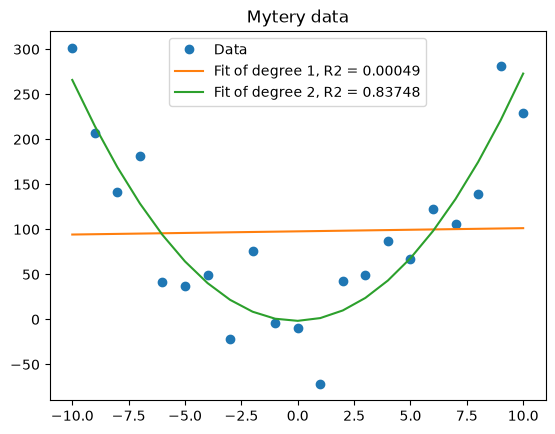

In [21]:
xVals, yVals = getData("../data/mysteryData.txt")

degrees = (1, 2)
models = genFits(xVals, yVals, degrees)
testFits(models, degrees, xVals, yVals, "Mytery data")

## Lets tests different specifications for this data

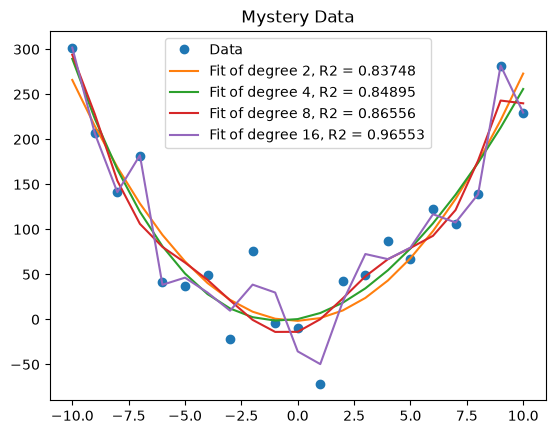

In [22]:
degrees = (2, 4, 8, 16)

models = genFits(xVals, yVals, degrees)
testFits(models, degrees, xVals, yVals, "Mystery Data")

- Interesing! The model with order 16 polynomio has the best R squared.. but doest that mean that is the best model?